In [1]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Install
# ════════════════════════════════════════════════════════════════

!pip install kagglehub xgboost optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.2 MB/s eta 0:00:00


In [2]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Imports
# ════════════════════════════════════════════════════════════════
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import optuna
import kagglehub

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics       import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"XGBoost : {xgb.__version__}")
print(f"Optuna  : {optuna.__version__}")


XGBoost : 3.2.0
Optuna  : 4.8.0


In [3]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Config
# ════════════════════════════════════════════════════════════════
DATASET   = "FD001"   # ← change to FD001 / FD002 / FD004
WINDOW    = 40
RUL_CLIP  = 125
N_TRIALS  = 75        # Optuna trials — more = better, ~8 min on T4

DROP_SENSORS  = ["s1", "s5", "s6", "s10", "s16", "s18", "s19"]

In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — Download dataset
# ════════════════════════════════════════════════════════════════
path = kagglehub.dataset_download("palbha/cmapss-jet-engine-simulated-data")
BASE = path
print(f"Path  : {BASE}")
print(f"Files : {os.listdir(BASE)}")

100%|██████████| 12.3M/12.3M [00:00<00:00, 82.1MB/s]

Extracting files...


Path  : /root/.cache/kagglehub/datasets/palbha/cmapss-jet-engine-simulated-data/versions/1
Files : ['test_FD001.txt', 'readme.txt', 'train_FD001.txt', 'train_FD002.txt', 'RUL_FD004.txt', 'Damage Propagation Modeling.pdf', 'train_FD003.txt', 'RUL_FD001.txt', 'test_FD003.txt', 'RUL_FD003.txt', 'test_FD002.txt', 'RUL_FD002.txt', 'train_FD004.txt', 'test_FD004.txt']


In [5]:


# ════════════════════════════════════════════════════════════════
# CELL 5 — Load data
# ════════════════════════════════════════════════════════════════
COL_NAMES = (
    ["engine_id", "cycle", "setting1", "setting2", "setting3"] +
    [f"s{i}" for i in range(1, 22)]
)

train = pd.read_csv(f"{BASE}/train_{DATASET}.txt",
                    sep=r"\s+", header=None, names=COL_NAMES)
test  = pd.read_csv(f"{BASE}/test_{DATASET}.txt",
                    sep=r"\s+", header=None, names=COL_NAMES)
rul_df = pd.read_csv(f"{BASE}/RUL_{DATASET}.txt",
                     sep=r"\s+", header=None, names=["RUL"])

train.dropna(axis=1, how="all", inplace=True)
test.dropna(axis=1, how="all",  inplace=True)

print(f"Train : {train.shape} | Test : {test.shape} | RUL : {rul_df.shape}")
print(f"Train engines : {train['engine_id'].nunique()}")
print(f"Test  engines : {test['engine_id'].nunique()}")


Train : (24720, 26) | Test : (16596, 26) | RUL : (100, 1)
Train engines : 100
Test  engines : 100


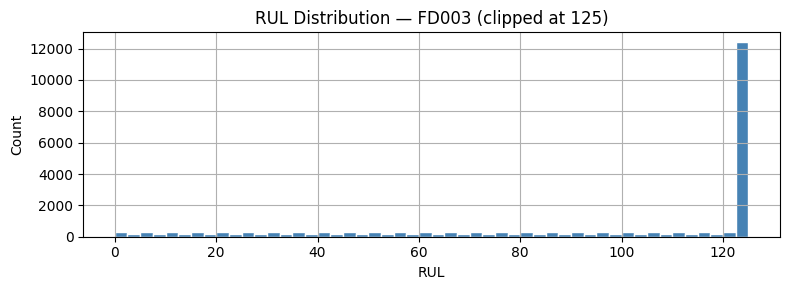

In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — RUL computation + clipping
# ════════════════════════════════════════════════════════════════
max_cyc = (train.groupby("engine_id")["cycle"]
               .max()
               .reset_index()
               .rename(columns={"cycle": "max_cycle"}))
train = train.merge(max_cyc, on="engine_id")
train["RUL"] = (train["max_cycle"] - train["cycle"]).clip(upper=RUL_CLIP)
train.drop(columns=["max_cycle"], inplace=True)

plt.figure(figsize=(8, 3))
train["RUL"].hist(bins=50, color="steelblue", edgecolor="white")
plt.title(f"RUL Distribution — {DATASET} (clipped at {RUL_CLIP})")
plt.xlabel("RUL"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

In [7]:



# ════════════════════════════════════════════════════════════════
# CELL 7 — Feature selection + drop low-variance sensors
# ════════════════════════════════════════════════════════════════
train.drop(columns=[c for c in DROP_SENSORS if c in train.columns], inplace=True)
test.drop( columns=[c for c in DROP_SENSORS if c in test.columns],  inplace=True)

SENSOR_COLS   = [c for c in train.columns
                 if c.startswith("s") and c in train.columns]
SETTING_COLS  = ["setting1", "setting2", "setting3"]
BASE_FEATURES = SETTING_COLS + SENSOR_COLS

print(f"Active sensors : {SENSOR_COLS}")
print(f"Base features  : {len(BASE_FEATURES)}")

Active sensors : ['setting1', 'setting2', 'setting3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Base features  : 20


In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — Rolling feature engineering
#   XGBoost has no memory → give it explicit temporal features
# ════════════════════════════════════════════════════════════════
def add_rolling_features(df, sensors):
    df = df.copy()
    for s in sensors:
        grp = df.groupby("engine_id")[s]
        df[f"{s}_mean5"]  = grp.transform(lambda x: x.rolling(5,  min_periods=1).mean())
        df[f"{s}_mean20"] = grp.transform(lambda x: x.rolling(20, min_periods=1).mean())
        df[f"{s}_std10"]  = grp.transform(lambda x: x.rolling(10, min_periods=1).std().fillna(0))
        df[f"{s}_delta"]  = grp.transform(lambda x: x.diff().fillna(0))
        df[f"{s}_rate"]   = df[f"{s}_delta"] / (df["cycle"] + 1)
    return df

train = add_rolling_features(train, SENSOR_COLS)
test  = add_rolling_features(test,  SENSOR_COLS)

FEATURE_COLS = [c for c in train.columns
                if c not in ["engine_id", "cycle", "RUL"]]

print(f"Total features after engineering: {len(FEATURE_COLS)}")


Total features after engineering: 102


In [9]:



# ════════════════════════════════════════════════════════════════
# CELL 9 — Normalize features
# ════════════════════════════════════════════════════════════════
feat_scaler = StandardScaler()
train[FEATURE_COLS] = feat_scaler.fit_transform(train[FEATURE_COLS])
test[FEATURE_COLS]  = feat_scaler.transform(test[FEATURE_COLS])

print("StandardScaler applied to features")

StandardScaler applied to features


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — Sequence generation
# ════════════════════════════════════════════════════════════════
def create_sequences(df, window, feature_cols):
    X, y = [], []
    for eid in df["engine_id"].unique():
        eng   = df[df["engine_id"] == eid].reset_index(drop=True)
        feats = eng[feature_cols].values
        rul   = eng["RUL"].values
        if len(eng) < window:
            continue
        for i in range(len(eng) - window):
            X.append(feats[i : i + window])
            y.append(rul[i + window])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

def get_last_sequences(df, window, feature_cols):
    X = []
    for eid in df["engine_id"].unique():
        eng   = df[df["engine_id"] == eid].reset_index(drop=True)
        feats = eng[feature_cols].values
        if len(eng) >= window:
            X.append(feats[-window:])
        else:
            pad = np.zeros((window - len(eng), len(feature_cols)))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

X_seq, y_seq   = create_sequences(train, WINDOW, FEATURE_COLS)
X_test_seq     = get_last_sequences(test, WINDOW, FEATURE_COLS)

print(f"X_seq      : {X_seq.shape}")
print(f"y_seq      : {y_seq.shape}")
print(f"X_test_seq : {X_test_seq.shape}")



X_seq      : (20720, 40, 102)
y_seq      : (20720,)
X_test_seq : (100, 40, 102)


In [11]:

# ════════════════════════════════════════════════════════════════
# CELL 11 — Engine-based train/val split (no leakage)
# ════════════════════════════════════════════════════════════════
all_engines   = train["engine_id"].unique()
n_val_eng     = int(0.2 * len(all_engines))
val_engines   = set(all_engines[-n_val_eng:])
train_engines = set(all_engines[:-n_val_eng])

train_df_split = train[train["engine_id"].isin(train_engines)]
val_df_split   = train[train["engine_id"].isin(val_engines)]

X_tr, y_tr = create_sequences(train_df_split, WINDOW, FEATURE_COLS)
X_vl, y_vl = create_sequences(val_df_split,   WINDOW, FEATURE_COLS)

print(f"Train engines : {len(train_engines)} → sequences: {X_tr.shape}")
print(f"Val   engines : {len(val_engines)}   → sequences: {X_vl.shape}")

Train engines : 80 → sequences: (16579, 40, 102)
Val   engines : 20   → sequences: (4141, 40, 102)


In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 13 — NASA Score helper
# ════════════════════════════════════════════════════════════════
def nasa_score(y_true, y_pred):
    diff  = y_pred - y_true
    score = np.where(diff < 0,
                     np.exp(-diff / 13) - 1,
                     np.exp( diff / 10) - 1)
    return np.sum(score)

In [13]:
# ════════════════════════════════════════════════════════════════
# CELL 12 — Build flat XGBoost feature vectors
#   last + mean + std + trend_rate + last 5 timesteps
# ════════════════════════════════════════════════════════════════
def build_xgb_features(X_seq):
    N, W, F = X_seq.shape
    last    = X_seq[:, -1, :]                          # current state
    mean_f  = X_seq.mean(axis=1)                       # average behavior
    std_f   = X_seq.std(axis=1)                        # variability
    trend   = (X_seq[:, -1, :] - X_seq[:, 0, :]) / W  # degradation rate
    last5   = X_seq[:, -5:, :].reshape(N, -1)          # recent 5 timesteps
    return np.hstack([last, mean_f, std_f, trend, last5])

X_xgb_train = build_xgb_features(X_tr)
X_xgb_val   = build_xgb_features(X_vl)
X_xgb_test  = build_xgb_features(X_test_seq)

# XGBoost trains on original RUL scale (not normalized)
y_xgb_train = y_tr.copy()
y_xgb_val   = y_vl.copy()
rul_true     = rul_df["RUL"].values

print(f"XGBoost train : {X_xgb_train.shape}")
print(f"XGBoost val   : {X_xgb_val.shape}")
print(f"XGBoost test  : {X_xgb_test.shape}")



XGBoost train : (16579, 918)
XGBoost val   : (4141, 918)
XGBoost test  : (100, 918)


In [ ]:

# ════════════════════════════════════════════════════════════════
# CELL 14 — Optuna hyperparameter search
# ════════════════════════════════════════════════════════════════
def objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 500, 2500),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"            : trial.suggest_float("gamma", 0.0, 5.0),
        "tree_method"      : "hist",
        "random_state"     : 42,
        "n_jobs"           : -1,
    }

    m = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    m.fit(
        X_xgb_train, y_xgb_train,
        eval_set=[(X_xgb_val, y_xgb_val)],
        verbose=False
    )

    preds = m.predict(X_xgb_val).clip(0, RUL_CLIP)
    return np.sqrt(mean_squared_error(y_xgb_val, preds))

print(f"Running {N_TRIALS} Optuna trials — please wait...")
study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest val RMSE : {study.best_value:.4f}")
print(f"Best params   :")
for k, v in study.best_params.items():
    print(f"  {k:25s}: {v}")

Running 75 Optuna trials — please wait...


  0%|          | 0/75 [00:00<?, ?it/s]

In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 15 — Train final model on best params
# ════════════════════════════════════════════════════════════════
best_p = study.best_params.copy()
best_p.update({"tree_method": "hist", "random_state": 42, "n_jobs": -1})

xgb_final = xgb.XGBRegressor(**best_p, early_stopping_rounds=50)
xgb_final.fit(
    X_xgb_train, y_xgb_train,
    eval_set=[(X_xgb_val, y_xgb_val)],
    verbose=100
)

# Save model
xgb_final.save_model(f"xgb_optuna_{DATASET}.json")
print(f"\nModel saved → xgb_optuna_{DATASET}.json")



In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 16 — Evaluate on test set
# ════════════════════════════════════════════════════════════════
preds_test = xgb_final.predict(X_xgb_test).clip(0, RUL_CLIP)

rmse_test  = np.sqrt(mean_squared_error(rul_true, preds_test))
nasa_test  = nasa_score(rul_true, preds_test)

print(f"\n{'='*50}")
print(f"  XGBoost + Optuna — {DATASET}")
print(f"  RMSE       : {rmse_test:.4f}")
print(f"  NASA Score : {nasa_test:.2f}")
print(f"{'='*50}")


In [ ]:


# ════════════════════════════════════════════════════════════════
# CELL 17 — Feature importance (top 20)
# ════════════════════════════════════════════════════════════════
F = len(FEATURE_COLS)
feat_names = (
    [f"last_{c}"   for c in FEATURE_COLS] +
    [f"mean_{c}"   for c in FEATURE_COLS] +
    [f"std_{c}"    for c in FEATURE_COLS] +
    [f"trend_{c}"  for c in FEATURE_COLS] +
    [f"t-{5-i}_{c}" for i in range(5) for c in FEATURE_COLS]
)

# Auto-check length
n_actual = X_xgb_train.shape[1]
assert len(feat_names) == n_actual, \
    f"feat_names={len(feat_names)} vs actual={n_actual}"

imp = pd.Series(xgb_final.feature_importances_, index=feat_names).nlargest(20)
plt.figure(figsize=(9, 6))
imp[::-1].plot(kind="barh", color="steelblue")
plt.title(f"XGBoost + Optuna — Top 20 Features ({DATASET})")
plt.tight_layout(); plt.show()


In [ ]:

# ════════════════════════════════════════════════════════════════
# CELL 18 — Optuna optimization history
# ════════════════════════════════════════════════════════════════
trials_df = study.trials_dataframe()

plt.figure(figsize=(10, 4))
plt.plot(trials_df["value"], alpha=0.4, color="steelblue", label="Trial RMSE")
plt.plot(trials_df["value"].cummin(), color="red", linewidth=2, label="Best so far")
plt.title(f"Optuna Optimization History — {DATASET}")
plt.xlabel("Trial"); plt.ylabel("Val RMSE")
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nTop 5 trials:")
print(trials_df.nsmallest(5, "value")[["number", "value"]].to_string(index=False))


In [ ]:

# ════════════════════════════════════════════════════════════════
# CELL 19 — Per-engine error analysis
# ════════════════════════════════════════════════════════════════
errors = preds_test - rul_true

plt.figure(figsize=(12, 4))
colors = ["tomato" if e > 0 else "steelblue" for e in errors]
plt.bar(range(len(errors)), errors, color=colors, width=0.7)
plt.axhline(0, color="black", linewidth=0.8)
plt.title(f"Per-Engine Prediction Error — {DATASET}\n"
          f"(Red = late = higher NASA penalty | Blue = early = safe)")
plt.xlabel("Engine Index"); plt.ylabel("Error (Pred − True)")
plt.tight_layout(); plt.show()

late  = (errors > 0).sum()
early = (errors < 0).sum()
print(f"Late  (risky) : {late}  ({100*late/len(errors):.1f}%)")
print(f"Early (safe)  : {early} ({100*early/len(errors):.1f}%)")
print(f"Mean error    : {errors.mean():.2f}")
print(f"Max late      : {errors.max():.2f}")
print(f"Max early     : {errors.min():.2f}")

In [ ]:

# ════════════════════════════════════════════════════════════════
# CELL 20 — Scatter: Predicted vs True RUL
# ════════════════════════════════════════════════════════════════
plt.figure(figsize=(6, 6))
plt.scatter(rul_true, preds_test, alpha=0.6, s=40, color="steelblue")
lim = max(rul_true.max(), preds_test.max()) + 5
plt.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("True RUL"); plt.ylabel("Predicted RUL")
plt.title(f"Predicted vs True RUL\nXGBoost + Optuna — {DATASET} | RMSE={rmse_test:.2f}")
plt.legend(); plt.tight_layout(); plt.show()